In [1]:
import os
import numpy as np
import pandas as pd
import torchvision
import torch
from PIL import Image, UnidentifiedImageError
from pathlib import Path
import random
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
import shutil
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import cv2

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

#import numpy as np # linear algebra
#import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

#import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
    #for filename in filenames:
        #print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
# things I have to do:
    # 1. Concat all the files and split them into train and test
    # 2. take a model, train them, and test them afterwards


In [4]:
file_path = '/kaggle/input/datasets/mustahid34/bangla-hand-written-digit'
folders = os.listdir(file_path)
folders

['BanglaHandWrittenDigit']

In [5]:
file_path

'/kaggle/input/datasets/mustahid34/bangla-hand-written-digit'

## Config

In [6]:
SEED = 42
TRAIN_RATIO = 0.75
VAL_RATIO = 0.15
TEST_RATIO = 0.1


# Select the Image size
IMG_SIZE = 64
BATCH_SIZE = 64
EPOCHS = 10
LR = 1E-3
NUM_WORKERS = 2

SOURCE_ROOT = Path('/kaggle/input/datasets/mustahid34/bangla-hand-written-digit')

# change the root
WORKING_ROOT = Path('/kaggle/working/bangla_digit_sample')
SPLIT_ROOT = Path(WORKING_ROOT/'data')

## Reproducibility

In [7]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")    

Using device: cpu


## Dataset Structure

In [8]:
source_path = Path('/kaggle/input/datasets/mustahid34/bangla-hand-written-digit/BanglaHandWrittenDigit')
print(source_path, type(source_path))

def get_data_structure(root):
    class_dirs = []
    for items in sorted(root.iterdir()):
        if items.is_dir():
            class_dirs.append(items)

    return class_dirs


class_dirs = get_data_structure(source_path)

# print the class directory
for dirs in class_dirs:
    print(f"Directories: {dirs.name}")

# length of each directory
for d in class_dirs:
    files = [f for f in d.iterdir() if f.is_file()]
    
    print(f"{d.name} contains: {len(files)}")

/kaggle/input/datasets/mustahid34/bangla-hand-written-digit/BanglaHandWrittenDigit <class 'pathlib.PosixPath'>
Directories: 0
Directories: 1
Directories: 2
Directories: 3
Directories: 4
Directories: 5
Directories: 6
Directories: 7
Directories: 8
Directories: 9
0 contains: 196
1 contains: 215
2 contains: 223
3 contains: 201
4 contains: 212
5 contains: 197
6 contains: 199
7 contains: 196
8 contains: 198
9 contains: 195


* 2 has the highest number of images
* 0 has the lowest number of images

* The image dataset is almost **balanced**

## Validate images and build file fast

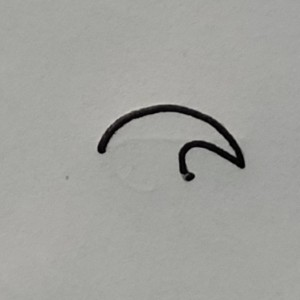

In [9]:
Image.open(files[0])

In [10]:
len(files)

195

In [11]:
class_dirs

[PosixPath('/kaggle/input/datasets/mustahid34/bangla-hand-written-digit/BanglaHandWrittenDigit/0'),
 PosixPath('/kaggle/input/datasets/mustahid34/bangla-hand-written-digit/BanglaHandWrittenDigit/1'),
 PosixPath('/kaggle/input/datasets/mustahid34/bangla-hand-written-digit/BanglaHandWrittenDigit/2'),
 PosixPath('/kaggle/input/datasets/mustahid34/bangla-hand-written-digit/BanglaHandWrittenDigit/3'),
 PosixPath('/kaggle/input/datasets/mustahid34/bangla-hand-written-digit/BanglaHandWrittenDigit/4'),
 PosixPath('/kaggle/input/datasets/mustahid34/bangla-hand-written-digit/BanglaHandWrittenDigit/5'),
 PosixPath('/kaggle/input/datasets/mustahid34/bangla-hand-written-digit/BanglaHandWrittenDigit/6'),
 PosixPath('/kaggle/input/datasets/mustahid34/bangla-hand-written-digit/BanglaHandWrittenDigit/7'),
 PosixPath('/kaggle/input/datasets/mustahid34/bangla-hand-written-digit/BanglaHandWrittenDigit/8'),
 PosixPath('/kaggle/input/datasets/mustahid34/bangla-hand-written-digit/BanglaHandWrittenDigit/9')]

In [12]:
VALID_EXTS = [".jpg", ".jpeg", ".png", ".webp", ".bmp"]

def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except (UnidentifiedImageError, OsError, ValueError):
        return False

all_samples = []
bad_files = []

for dirs in class_dirs:
    label = dirs.name
    for file_path in dirs.iterdir():
        if file_path.is_file() and file_path.suffix.lower() in VALID_EXTS:
                if is_valid_image(file_path):
                    all_samples.append({
                        "filepath": str(file_path),
                        "label": label
                    })
                else:
                    bad_files.append(str(file_path))
                    
df = pd.DataFrame(all_samples)
bad_df = pd.DataFrame({"bad_filepath": bad_files})

print("Valid samples: ", len(df))
print("Bad files:" , len(bad_df))

display(df.head())
if len(bad_df)>0:
    display(bad_df.head())

Valid samples:  2032
Bad files: 0


,filepath,label
0,/kaggle/input/datasets/mustahid34/bangla-hand-...,0
1,/kaggle/input/datasets/mustahid34/bangla-hand-...,0
2,/kaggle/input/datasets/mustahid34/bangla-hand-...,0
3,/kaggle/input/datasets/mustahid34/bangla-hand-...,0
4,/kaggle/input/datasets/mustahid34/bangla-hand-...,0


In [13]:
print(df['label'].value_counts().sort_index())

label
0    196
1    215
2    223
3    201
4    212
5    197
6    199
7    196
8    198
9    195
Name: count, dtype: int64


In [14]:
# check class balance
print(df['label'].value_counts().sort_index())

label
0    196
1    215
2    223
3    201
4    212
5    197
6    199
7    196
8    198
9    195
Name: count, dtype: int64


## Train/Val/Test Split

In [15]:
train_df, temp_df = train_test_split(
    df,
    test_size = (1-TRAIN_RATIO),
    stratify = df["label"],
    random_state = SEED
)

relative_test_ratio = TEST_RATIO/ (VAL_RATIO + TEST_RATIO)

val_df, test_df = train_test_split(
    temp_df,
    test_size = relative_test_ratio,
    stratify = temp_df["label"],
    random_state = SEED
)

print(f"Train: {len(train_df)}")
print(f"val: {len(val_df)}")
print(f"Test{len(test_df)}")

print("\nTrain class distribution:")
print(train_df["label"].value_counts().sort_index())

print("\nVal class distribution:")
print(val_df["label"].value_counts().sort_index())

print("\nTest class distribution:")
print(test_df["label"].value_counts().sort_index())

Train: 1524
val: 304
Test204

Train class distribution:
label
0    147
1    161
2    167
3    151
4    159
5    148
6    149
7    147
8    149
9    146
Name: count, dtype: int64

Val class distribution:
label
0    29
1    32
2    34
3    30
4    32
5    30
6    30
7    29
8    29
9    29
Name: count, dtype: int64

Test class distribution:
label
0    20
1    22
2    22
3    20
4    21
5    19
6    20
7    20
8    20
9    20
Name: count, dtype: int64


## Copy files into split folders

In [16]:
# create split folders
def create_split_folders(root, class_names):
    if root.exists():
        shutil.rmtree(root)


    # Create train, val, test folders
    for split in ['train', 'val', 'test']:
        for cls in class_names:
            folder_path = root/split/cls
            folder_path.mkdir(parents = True, exist_ok = True)


        
class_names = sorted(df['label'].unique())

# create empty train/val/test folders
create_split_folders(SPLIT_ROOT, class_names)


# This function copies images into those folders
def copy_samples(split_df, split_name, dest_root):
    for _,row in split_df.iterrows():
        source_file = Path(row['filepath']) # original image path
        label = row["label"] # class label like 0,1,2
        destination_file = dest_root/split_name/label/source_file.name

        shutil.copy2(source_file, destination_file)


# Copy images into them
copy_samples(train_df, 'train', SPLIT_ROOT)
copy_samples(test_df, 'test', SPLIT_ROOT)
copy_samples(val_df, 'val', SPLIT_ROOT)
        

In [17]:
SPLIT_ROOT

PosixPath('/kaggle/working/bangla_digit_sample/data')

In [18]:
data_dir = Path(file_path)
full_image_dataset = list(data_dir.glob('*/*/*.jpg'))

In [19]:
len(full_image_dataset)

0

In [20]:
file_path = '/kaggle/input/datasets/mustahid34/bangla-hand-written-digit/BanglaHandWrittenDigit'
for cls in os.listdir(file_path):
    print(f"{cls}: {len(os.listdir(os.path.join(file_path,cls)))}")

7: 196
2: 223
5: 197
8: 198
0: 196
3: 201
1: 215
4: 212
9: 195
6: 199


In [21]:
print(os.listdir(file_path))

['7', '2', '5', '8', '0', '3', '1', '4', '9', '6']


In [22]:

PRACTICE_PATH = Path('/kaggle/working/practice')
PRACTICE_PATH.mkdir(parents = True, exist_ok = True)

In [23]:
# create empty folders
def empty_folders(root_path,class_name):
    if root_path.exists():
        shutil.rmtree(root_path)

    for folder in ['train', 'val', 'test']:
        for cls in class_name:
            (root_path/folder/cls).mkdir(parents = True, exist_ok = True)

class_name = sorted(df['label'].unique())
empty_folders(PRACTICE_PATH, class_name)


# copy from the df to the main practice folders
def copy_images(split_df, split_name, dest_dir):
    for _, row in split_df.iterrows():
        source_file = Path(row['filepath'])
        label = row['label']
        destination_file = dest_dir/split_name/label/source_file.name

        shutil.copy2(source_file, destination_file)


copy_images(train_df, 'train', PRACTICE_PATH)

now we got the full data in a usable format

 ## Helper Function

In [24]:
import matplotlib.pyplot as plt
def plot_img(n:int,
            img_dir):
    if n>10:
        print('It can show 10 pics at a time at a max')
        n = 10

    
    random_img = random.sample(img_dir, n)

    #create the subplot
    fig, axs = plt.subplots(1,n, figsize = (16,8))
    

    for serial,img in enumerate(random_img):
        with Image.open(img) as f:
            axs[serial].imshow(f)
            axs[serial].set_title(img.parent.name)
            axs[serial].axis('off')
    plt.tight_layout()
    plt.show()
            

In [25]:
# train plot img
def make_all_trainfiles_list(path):
    train_img_file = []
    for dirs in path.iterdir():
        for files in dirs.iterdir():
            if files.is_file():
                train_img_file.append(files)

    return train_img_file

train_images_file = make_all_trainfiles_list(Path('/kaggle/working/practice/train'))
        
        

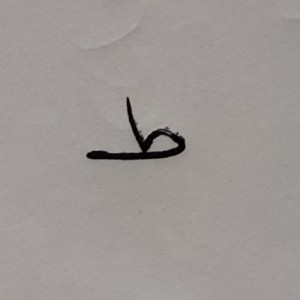

In [26]:
Image.open(train_images_file[542])

## Plot some training Images

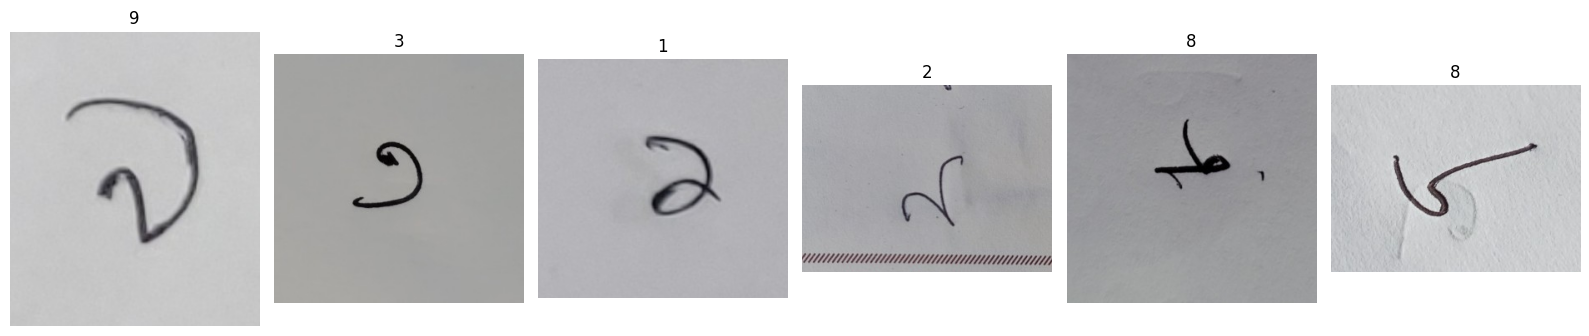

In [27]:
plot_img(n = 6,
        img_dir = train_images_file)

(np.float64(-0.5), np.float64(299.5), np.float64(224.5), np.float64(-0.5))

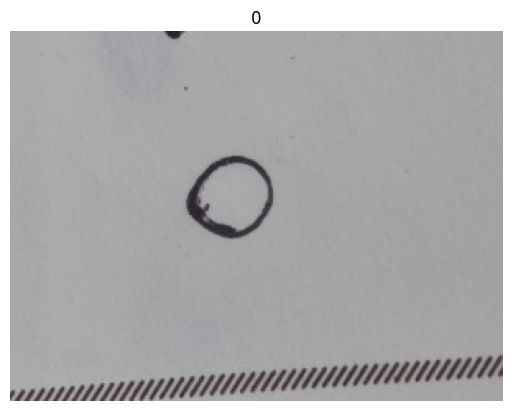

In [28]:
import matplotlib.pyplot as plt
sample_img = '/kaggle/working/bangla_digit_sample/data/train/0/0_25.jpg'
converted_img = plt.imread(sample_img)
label = Path(sample_img).parent.name
plt.imshow(converted_img)
plt.title(label)
plt.axis(False)

## Transform Function

In [29]:
from torchvision import transforms

train_transform_function = transforms.Compose([
    transforms.Grayscale(num_output_channels =3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees = 0, translate = (0.05,0.05), scale = (0.8,1.2)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.5], std = [0.5])
    
]
)

eval_transform_function = transforms.Compose([
    transforms.Grayscale(num_output_channels =3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.5], std = [0.5])
    
]
)

## Create the Dataset

In [30]:
from torchvision import datasets

train_dataset = datasets.ImageFolder(SPLIT_ROOT/'train',
                                    transform = train_transform_function)
eval_dataset = datasets.ImageFolder(SPLIT_ROOT/'val',
                                   transform = eval_transform_function)
test_dataset = datasets.ImageFolder(SPLIT_ROOT/'test',
                                   transform = eval_transform_function)

## DataLoader

In [31]:
from torch.utils.data import DataLoader
train_dataloader = DataLoader(train_dataset,
                             batch_size = BATCH_SIZE,
                             shuffle = True,
                             num_workers = NUM_WORKERS)
eval_dataloader = DataLoader(eval_dataset,
                             batch_size = BATCH_SIZE,
                             shuffle = False,
                             num_workers = NUM_WORKERS)
test_dataloader = DataLoader(test_dataset,
                             batch_size = BATCH_SIZE,
                             shuffle = False,
                             num_workers = NUM_WORKERS)

In [32]:
# first dataloader batch
img,label = next(iter(train_dataloader))
img,label

(tensor([[[[-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000,  ...,  0.6706,  0.6471, -1.0000],
           ...,
           [-1.0000, -1.0000, -1.0000,  ...,  0.4196,  0.4196, -1.0000],
           [-1.0000, -1.0000, -1.0000,  ...,  0.4353,  0.4196, -1.0000],
           [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000]],
 
          [[-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000,  ...,  0.6706,  0.6471, -1.0000],
           ...,
           [-1.0000, -1.0000, -1.0000,  ...,  0.4196,  0.4196, -1.0000],
           [-1.0000, -1.0000, -1.0000,  ...,  0.4353,  0.4196, -1.0000],
           [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000]],
 
          [[-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
           [-

# Device Agnostic Code

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

## Create a Simple CNN Model

In [34]:
import torch.nn as nn
class Model(nn.Module):
    def __init__(self,num_classes = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels = 3,
                     out_channels = 32,
                     kernel_size = 3,
                     padding = 1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels = 32,
                     out_channels = 64,
                     kernel_size = 3,
                     padding = 1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels = 64,
                     out_channels = 128,
                     kernel_size = 3,
                     padding = 1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2)
            )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*8*8,256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256,num_classes)
        )

    def forward(self,x):
        x = self.features(x)
        x = self.classifier(x)
        return x

basic_model = Model(num_classes = 10).to(device)

In [35]:
# pass one batch image
with torch.inference_mode():
    img, label = img.to(device), label.to(device)
    output_label = basic_model(img)
    output_label = output_label.argmax(dim = 1)
    print(f"predicted label: {output_label}")
    print(f"original label: {label}")
    

predicted label: tensor([5, 9, 1, 1, 3, 8, 8, 9, 8, 7, 4, 6, 4, 9, 7, 8, 6, 9, 9, 4, 6, 1, 4, 8,
        2, 8, 0, 4, 2, 8, 6, 9, 9, 9, 0, 9, 9, 8, 4, 2, 9, 4, 9, 0, 6, 7, 9, 9,
        6, 0, 9, 6, 6, 7, 7, 7, 8, 6, 1, 9, 8, 8, 6, 1])
original label: tensor([8, 2, 5, 8, 8, 4, 1, 1, 3, 3, 4, 9, 6, 3, 8, 0, 2, 1, 7, 9, 6, 1, 2, 3,
        5, 7, 5, 5, 0, 1, 3, 5, 7, 8, 3, 0, 3, 6, 0, 0, 6, 4, 0, 0, 6, 1, 9, 1,
        1, 6, 5, 6, 6, 7, 2, 4, 1, 8, 8, 8, 6, 1, 3, 9])


## Accuracy Function

In [36]:
def accuracy_function(pred,actual):
    corrected_count = (pred==actual).sum().item()
    accuracy = (corrected_count/len(pred))*100
    return accuracy

In [37]:
initial_acc = accuracy_function(output_label, label)
print(f"initial accuracy {initial_acc}%")

initial accuracy 15.625%


## Loss Function and Optimizer 

In [38]:
loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(basic_model.parameters(), lr = LR)
print(basic_model)

Model(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=

## Training and Validation Function

In [39]:
def train(model:torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
         loss_function: torch.nn.Module,
         optimizer: torch.optim.Optimizer,
          device
         ):

    running_loss = 0.0
    preds_all = []
    labels_all = []

    # pass the model into train mode
    model.train()
    model.to(device)
    for idx, (img,label) in enumerate(train_dataloader):
        img,label = img.to(device), label.to(device)

        optimizer.zero_grad()
        # pass the image to the model
        pred_prob = model(img)
        pred_label = pred_prob.argmax(dim = 1)

        loss = loss_function(pred_prob,label)
        # backward propagation
        loss.backward()
        # optimizer step
        optimizer.step()

        # calculate accumulate loss
        running_loss += loss.item()* img.size(0)
        preds_all.extend(pred_label.cpu().numpy())
        labels_all.extend(label.cpu().numpy())

    epoch_loss = running_loss/len(train_dataloader.dataset)
    epoch_acc = accuracy_function(torch.tensor(preds_all), torch.tensor(labels_all))

    return epoch_loss, epoch_acc



def validation(val_dataloader : torch.utils.data.DataLoader,
              model: torch.nn.Module,
              device,
              loss_function: torch.nn.Module):

    # pass the model to the appropriate device
    model.to(device)
    # convert the model into evaluation mode
    model.eval()
    running_loss = 0.0
    preds_all = []
    labels_all = []

    with torch.inference_mode():
        for img,label in val_dataloader:
            img, label = img.to(device), label.to(device)
            # pass the img to the model
            pred_prob = model(img)
            loss = loss_function(pred_prob,label)
            running_loss +=loss.item() * img.size(0)
            preds = pred_prob.argmax(dim = 1)

            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(label.cpu().numpy())

    epoch_loss = running_loss/len(val_dataloader.dataset)
    epoch_acc = accuracy_function(torch.tensor(preds_all), torch.tensor(labels_all))
    return epoch_loss, epoch_acc, labels_all, preds_all
            

## Train Model

In [40]:
best_val_acc = 0.0
best_basic_model_path = WORKING_ROOT/"best_simple_cnn.pth"

history = []

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model = basic_model,
                                 train_dataloader = train_dataloader,
                                 loss_function = loss_function,
                                 optimizer = optimizer,
                                 device= device)
    val_loss, val_acc, _, _ = validation(val_dataloader = eval_dataloader,
                                        model = basic_model,
                                        device = device,
                                        loss_function = loss_function)
    history.append({
        "epoch":epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc":val_acc
    })

    print(f"Epoch [{epoch+1}/{EPOCHS}]"
         f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} |"
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    if val_acc>best_val_acc:
        best_val_acc = val_acc
        torch.save(basic_model.state_dict(), best_basic_model_path)

print(f"\nBest Validation Accuracy: {best_val_acc}")
print(f"Best model saved to: {best_basic_model_path}")

Epoch [1/10]Train Loss: 2.7432 | Train Acc: 12.9265 |Val Loss: 2.4574 | Val Acc: 11.5132
Epoch [2/10]Train Loss: 2.1685 | Train Acc: 21.0630 |Val Loss: 2.3215 | Val Acc: 18.7500
Epoch [3/10]Train Loss: 1.9566 | Train Acc: 30.0525 |Val Loss: 1.5911 | Val Acc: 49.6711
Epoch [4/10]Train Loss: 1.6931 | Train Acc: 40.9449 |Val Loss: 1.2917 | Val Acc: 58.8816
Epoch [5/10]Train Loss: 1.4301 | Train Acc: 51.0499 |Val Loss: 0.9608 | Val Acc: 69.7368
Epoch [6/10]Train Loss: 1.1079 | Train Acc: 62.0735 |Val Loss: 0.8115 | Val Acc: 75.3289
Epoch [7/10]Train Loss: 0.9515 | Train Acc: 67.5853 |Val Loss: 0.6144 | Val Acc: 82.2368
Epoch [8/10]Train Loss: 0.7943 | Train Acc: 72.9003 |Val Loss: 0.6088 | Val Acc: 78.9474
Epoch [9/10]Train Loss: 0.7207 | Train Acc: 75.9186 |Val Loss: 0.5175 | Val Acc: 84.2105
Epoch [10/10]Train Loss: 0.6239 | Train Acc: 80.3150 |Val Loss: 0.4438 | Val Acc: 85.1974

Best Validation Accuracy: 85.19736842105263
Best model saved to: /kaggle/working/bangla_digit_sample/best_si

## Plot loss and Accuracy

In [41]:
history

[{'epoch': 1,
  'train_loss': 2.743228275319097,
  'train_acc': 12.926509186351707,
  'val_loss': 2.457438506578144,
  'val_acc': 11.513157894736842},
 {'epoch': 2,
  'train_loss': 2.1684953108860126,
  'train_acc': 21.062992125984252,
  'val_loss': 2.3214574613069234,
  'val_acc': 18.75},
 {'epoch': 3,
  'train_loss': 1.9565638532162963,
  'train_acc': 30.05249343832021,
  'val_loss': 1.5911110890539069,
  'val_acc': 49.67105263157895},
 {'epoch': 4,
  'train_loss': 1.6930913155473124,
  'train_acc': 40.94488188976378,
  'val_loss': 1.291696592381126,
  'val_acc': 58.88157894736842},
 {'epoch': 5,
  'train_loss': 1.4301049136740016,
  'train_acc': 51.0498687664042,
  'val_loss': 0.9608002305030823,
  'val_acc': 69.73684210526315},
 {'epoch': 6,
  'train_loss': 1.1078972480115614,
  'train_acc': 62.07349081364829,
  'val_loss': 0.8115231332026029,
  'val_acc': 75.32894736842105},
 {'epoch': 7,
  'train_loss': 0.9514801802597647,
  'train_acc': 67.58530183727034,
  'val_loss': 0.6144106

In [42]:
history_df =pd.DataFrame(history)

In [43]:
history_df

,epoch,train_loss,train_acc,val_loss,val_acc
0,1,2.743228,12.926509,2.457439,11.513158
1,2,2.168495,21.062992,2.321457,18.750000
2,3,1.956564,30.052493,1.591111,49.671053
3,4,1.693091,40.944882,1.291697,58.881579
4,5,1.430105,51.049869,0.960800,69.736842
5,6,1.107897,62.073491,0.811523,75.328947
6,7,0.951480,67.585302,0.614411,82.236842
7,8,0.794332,72.900262,0.608792,78.947368
8,9,0.720721,75.918635,0.517490,84.210526
9,10,0.623852,80.314961,0.443769,85.197368


## Plot the loss and accuracy curve

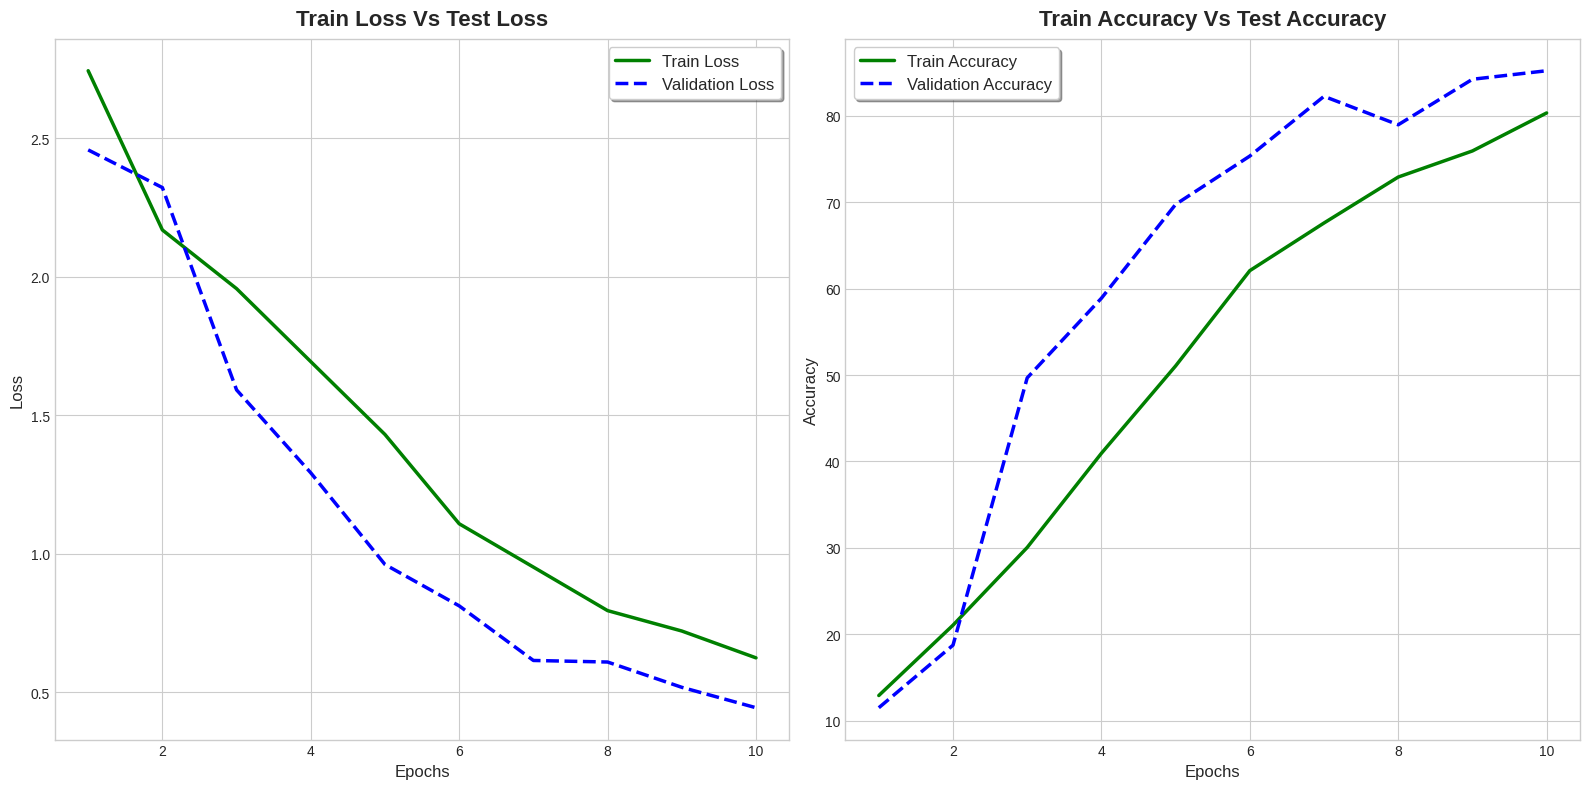

In [44]:
import matplotlib.pyplot as plt

def plot_loss_acc(history_df):
    # 1. Apply a clean background style (optional but looks great)
    plt.style.use('seaborn-v0_8-whitegrid')
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 8))

    # --- PLOT 1: LOSS ---
    # FIXED: Added the `label` parameter to both plots so the legend knows what to say.
    # UPGRADE: Changed Train to a solid line ('-') and kept Validation dashed ('--').
    ax[0].plot(history_df['epoch'], history_df['train_loss'], color='green', linestyle='-', linewidth=2.5, label='Train Loss')
    ax[0].plot(history_df['epoch'], history_df['val_loss'], color='blue', linestyle='--', linewidth=2.5, label='Validation Loss')
    
    ax[0].set_title('Train Loss Vs Test Loss', fontsize=16, fontweight='bold', pad=10)
    ax[0].set_xlabel('Epochs', fontsize=12)
    ax[0].set_ylabel('Loss', fontsize=12)
    
    # FIXED: This one line actually draws the legend onto the graph!
    ax[0].legend(fontsize=12, frameon=True, shadow=True)

    # --- PLOT 2: ACCURACY ---
    # FIXED: Added `label` parameters here too.
    ax[1].plot(history_df['epoch'], history_df['train_acc'], color='green', linestyle='-', linewidth=2.5, label='Train Accuracy')
    ax[1].plot(history_df['epoch'], history_df['val_acc'], color='blue', linestyle='--', linewidth=2.5, label='Validation Accuracy')
    
    ax[1].set_title('Train Accuracy Vs Test Accuracy', fontsize=16, fontweight='bold', pad=10)
    ax[1].set_xlabel('Epochs', fontsize=12)
    ax[1].set_ylabel('Accuracy', fontsize=12)
    
    # FIXED: Draw the legend for the accuracy graph.
    ax[1].legend(fontsize=12, frameon=True, shadow=True)
    plt.savefig(WORKING_ROOT/'loss_acc_curve', dpi = 300, bbox_inches = 'tight')
    # UPGRADE: This prevents the labels from overlapping with the graph titles
    plt.tight_layout()
    plt.show()

# Run it!
plot_loss_acc(history_df)

## Test Evaluation

In [45]:
basic_model.load_state_dict(torch.load(best_basic_model_path, map_location = device))
test_loss, test_acc, y_true, y_pred = validation(val_dataloader = test_dataloader,model = basic_model,
                                                 device = device, loss_function = loss_function
                                                )
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")
print(classification_report(y_true, y_pred, target_names=train_dataset.classes))


Test Loss: 0.5397462985094856
Test Accuracy: 83.82352941176471
              precision    recall  f1-score   support

           0       0.94      0.80      0.86        20
           1       0.85      0.77      0.81        22
           2       0.90      0.86      0.88        22
           3       0.68      0.95      0.79        20
           4       0.77      0.81      0.79        21
           5       0.81      0.68      0.74        19
           6       0.94      0.80      0.86        20
           7       0.90      0.95      0.93        20
           8       0.87      1.00      0.93        20
           9       0.79      0.75      0.77        20

    accuracy                           0.84       204
   macro avg       0.85      0.84      0.84       204
weighted avg       0.85      0.84      0.84       204



## Classification Matrix on Train, Eval and Test

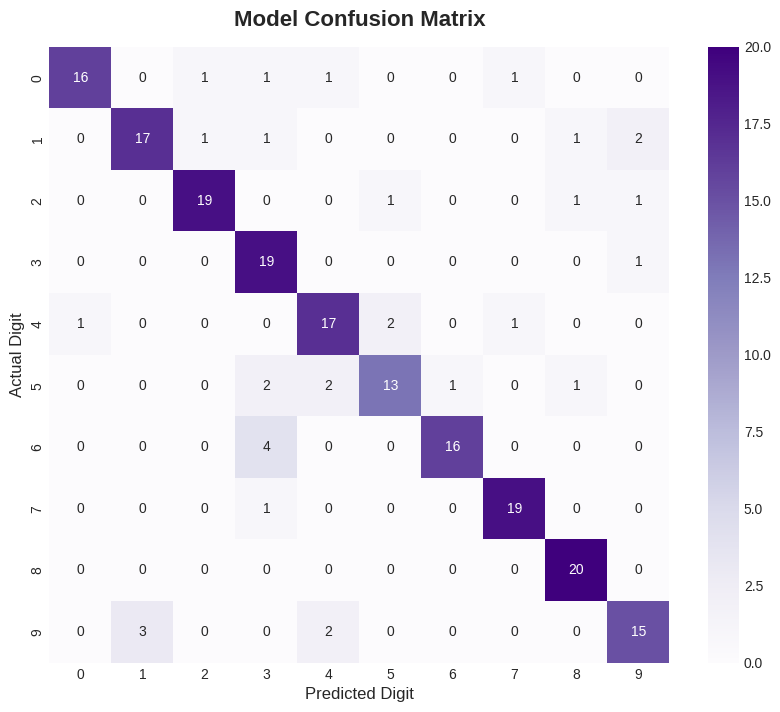

In [46]:
# Calculate the raw confusion matrix numbers
cm = confusion_matrix(y_true, y_pred)

# Plot it as a beautiful heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=train_dataset.classes, 
            yticklabels=train_dataset.classes)

plt.title('Model Confusion Matrix', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Predicted Digit', fontsize=12)
plt.ylabel('Actual Digit', fontsize=12)



heatmap_file = WORKING_ROOT/'heatmap.png'
plt.savefig(heatmap_file, dpi = 300, bbox_inches = 'tight')

plt.show()

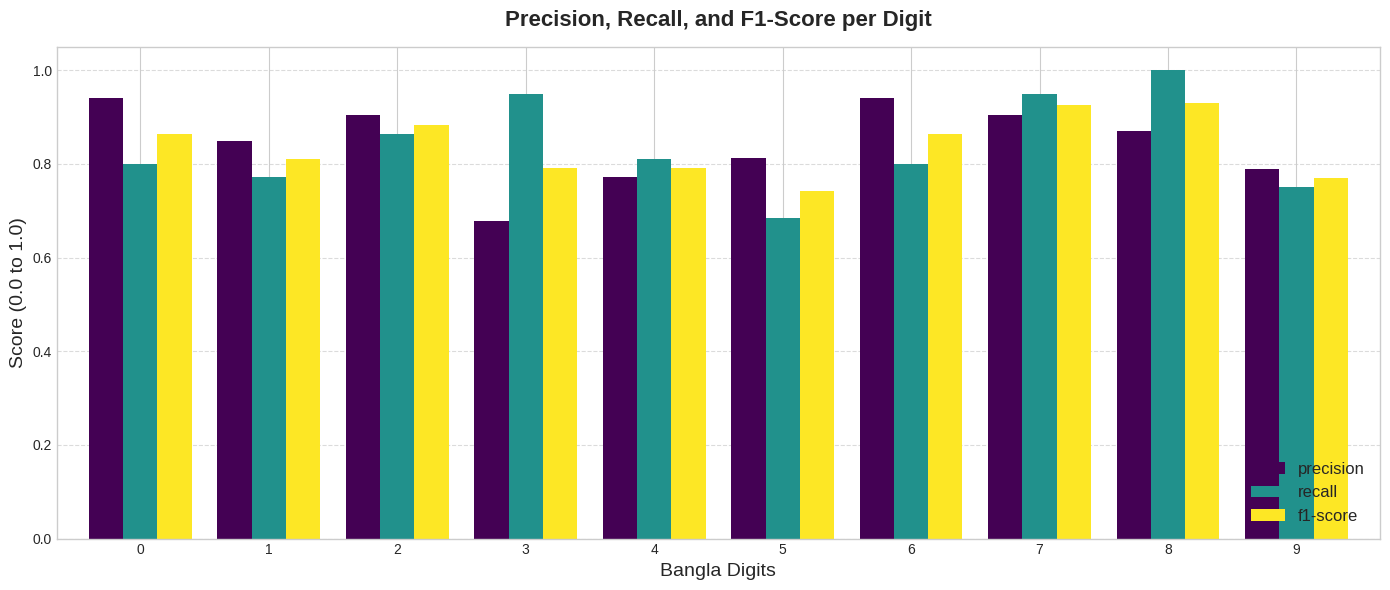

In [47]:
# 1. Get the dictionary and convert to DataFrame (just like before)
report_dict = classification_report(y_true, y_pred, target_names=train_dataset.classes, output_dict=True)
report_df = pd.DataFrame(report_dict).T

# 2. Drop the 'accuracy', 'macro avg', and 'weighted avg' rows so we only plot the digits
report_df = report_df.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

# 3. Create a beautiful grouped bar chart
fig, ax = plt.subplots(figsize=(14, 6))

# Plot Precision, Recall, and F1-score (ignoring 'support')
report_df[['precision', 'recall', 'f1-score']].plot(kind='bar', ax=ax, width=0.8, colormap='viridis')

plt.title('Precision, Recall, and F1-Score per Digit', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Bangla Digits', fontsize=14)
plt.ylabel('Score (0.0 to 1.0)', fontsize=14)
plt.xticks(rotation=0)
plt.legend(loc='lower right', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

precision_recall_f1score_graph_path = WORKING_ROOT/'precision_recall_f1.png'
plt.savefig(precision_recall_f1score_graph_path, dpi = 300, bbox_inches = 'tight')

plt.tight_layout()
plt.show()

## Save Report and Final Test Report

In [48]:
report_df

,precision,recall,f1-score,support
0,0.941176,0.800000,0.864865,20.0
1,0.850000,0.772727,0.809524,22.0
2,0.904762,0.863636,0.883721,22.0
3,0.678571,0.950000,0.791667,20.0
4,0.772727,0.809524,0.790698,21.0
5,0.812500,0.684211,0.742857,19.0
6,0.941176,0.800000,0.864865,20.0
7,0.904762,0.950000,0.926829,20.0
8,0.869565,1.000000,0.930233,20.0
9,0.789474,0.750000,0.769231,20.0


In [49]:
report_file = WORKING_ROOT/'report.csv'
# save the report file
report_df.to_csv(report_file)

In [50]:
history_path = WORKING_ROOT/'training_history.csv'
history_df.to_csv(history_path, index = False)

## Inferencing on One Image

In [51]:
def inferencing_image(img_path, model_path,transform):
    trg_img_path = Path(img_path)
    # load & open the image
    img = Image.open(trg_img_path)
    label = trg_img_path.parent.name
    # transform the img
    transformed_img = transform(img).unsqueeze(dim = 0)
    print(f"shape of transformed img: {transformed_img.shape}")
    
    # Pass the image to the model 
    with torch.inference_mode():
        output = model_path(transformed_img)
        pred = output.argmax(dim = 1)

    # show the image according with the label
    plt.imshow(plt.imread(img_path))
    plt.title(f"Actual Label: {label} | Predicted Label: {pred.item()}")
    
    plt.axis(False)
    plt.show()

In [52]:
f = Image.open(train_images_file[10])
f = eval_transform_function(f).unsqueeze(dim = 0)
f.shape
    

# pass the image to the model
with torch.inference_mode():
    
    output = basic_model(f)
    pred = output.argmax(dim =1)

print(pred)

tensor([1])


In [53]:
sample_img_dir = WORKING_ROOT/'sample_img'
sample_img_dir.mkdir(parents = True, exist_ok = True)

In [54]:
sample_img_dir

PosixPath('/kaggle/working/bangla_digit_sample/sample_img')

In [55]:
source_file = Path('/kaggle/input/datasets/tinonturjamajumder/an-image-of-a-bangla-digit/IMG_2775.JPG')
destination_file = Path("/kaggle/working/bangla_digit_sample/sample_img/my_img.jpg")
shutil.copy2(source_file,destination_file)



PosixPath('/kaggle/working/bangla_digit_sample/sample_img/my_img.jpg')

shape of transformed img: torch.Size([1, 3, 64, 64])


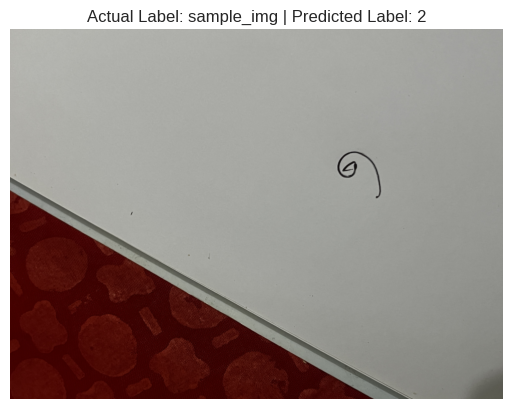

In [56]:

basic_model.load_state_dict(torch.load(best_basic_model_path, map_location = device))
img_path = '/kaggle/working/bangla_digit_sample/sample_img/my_img.jpg'
inferencing_image(img_path = img_path,
                 model_path = basic_model,
                 transform = eval_transform_function)



In [57]:
source_file = Path('/kaggle/input/datasets/tinonturjamajumder/an-image-of-a-bangla-digit/IMG_2776.jpg')
destination_file = Path("/kaggle/working/bangla_digit_sample/sample_img/img_2.jpg")
shutil.copy2(source_file,destination_file)



PosixPath('/kaggle/working/bangla_digit_sample/sample_img/img_2.jpg')

In [58]:

best_basic_model_path

PosixPath('/kaggle/working/bangla_digit_sample/best_simple_cnn.pth')

shape of transformed img: torch.Size([1, 3, 64, 64])


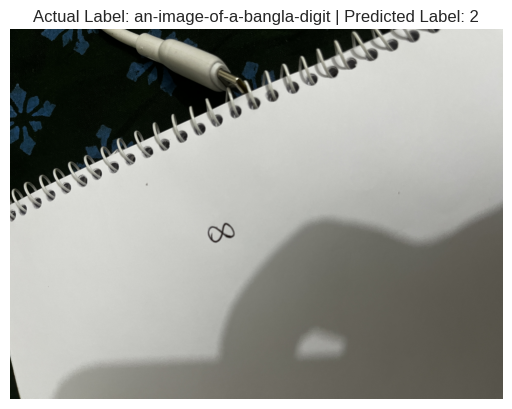

In [59]:
basic_model.load_state_dict(torch.load(best_basic_model_path, map_location = device))
img_path = '/kaggle/input/datasets/tinonturjamajumder/an-image-of-a-bangla-digit/IMG_2779.JPG'
inferencing_image(img_path = img_path,
                 model_path = basic_model,
                 transform = eval_transform_function)


## Use Transfer Learning

In [60]:
from torchvision.models import resnet50, ResNet50_Weights
transfer_model = resnet50(weights = ResNet50_Weights.IMAGENET1K_V2)
#for param in transfer_model.parameters():
    #param.requires_grad = False

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 293MB/s]


In [61]:
## freze the final layer 
print(transfer_model.fc)


Linear(in_features=2048, out_features=1000, bias=True)


In [62]:
in_feat = transfer_model.fc.in_features
transfer_model.fc = nn.Linear(in_feat, out_features = 10)

In [63]:
print(transfer_model.fc)

Linear(in_features=2048, out_features=10, bias=True)


## Training with Transfer Learning Model


In [64]:
EPOCHS = 10
loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(transfer_model.parameters(), lr = LR)

best_val_acc = 0.0
best_model_path = WORKING_ROOT/"best_resnet50.pth"

history = []


for epoch in range(EPOCHS):
    train_loss, train_acc = train(model = transfer_model,
                                 train_dataloader = train_dataloader,
                                 loss_function = loss_function,
                                 optimizer = optimizer,
                                 device= device)
    val_loss, val_acc, _, _ = validation(val_dataloader = eval_dataloader,
                                        model = transfer_model,
                                        device = device,
                                        loss_function = loss_function)
    history.append({
        "epoch":epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc":val_acc
    })

    print(f"Epoch [{epoch+1}/{EPOCHS}]"
         f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} |"
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    if val_acc>best_val_acc:
        best_val_acc = val_acc
        torch.save(transfer_model.state_dict(), best_model_path)

print(f"\nBest Validation Accuracy: {best_val_acc}")
print(f"Best model saved to: {best_model_path}")

Epoch [1/10]Train Loss: 1.3480 | Train Acc: 54.9869 |Val Loss: 1.5535 | Val Acc: 65.7895
Epoch [2/10]Train Loss: 0.5034 | Train Acc: 85.2362 |Val Loss: 0.3044 | Val Acc: 87.1711
Epoch [3/10]Train Loss: 0.2866 | Train Acc: 91.4698 |Val Loss: 0.2856 | Val Acc: 90.1316
Epoch [4/10]Train Loss: 0.2227 | Train Acc: 93.3727 |Val Loss: 0.3402 | Val Acc: 90.1316
Epoch [5/10]Train Loss: 0.2130 | Train Acc: 93.5696 |Val Loss: 0.1134 | Val Acc: 96.3816
Epoch [6/10]Train Loss: 0.1790 | Train Acc: 94.4226 |Val Loss: 0.4813 | Val Acc: 85.8553
Epoch [7/10]Train Loss: 0.1692 | Train Acc: 94.4882 |Val Loss: 0.2051 | Val Acc: 94.7368
Epoch [8/10]Train Loss: 0.1515 | Train Acc: 95.8005 |Val Loss: 0.0879 | Val Acc: 97.0395
Epoch [9/10]Train Loss: 0.1210 | Train Acc: 96.3255 |Val Loss: 0.1418 | Val Acc: 95.3947
Epoch [10/10]Train Loss: 0.1325 | Train Acc: 96.1942 |Val Loss: 0.1659 | Val Acc: 95.3947

Best Validation Accuracy: 97.03947368421053
Best model saved to: /kaggle/working/bangla_digit_sample/best_re

## CHECK PERFORMANCE ON TEST DATASET

In [65]:
test_loss, test_acc, y_true, y_pred = validation(val_dataloader = test_dataloader,model = transfer_model,
                                                 device = device, loss_function = loss_function
                                                )
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")
print(classification_report(y_true, y_pred, target_names=train_dataset.classes))


Test Loss: 0.21416665993484796
Test Accuracy: 93.62745098039215
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        20
           1       0.87      0.91      0.89        22
           2       0.84      0.95      0.89        22
           3       1.00      0.95      0.97        20
           4       0.95      0.90      0.93        21
           5       0.90      0.95      0.92        19
           6       1.00      0.95      0.97        20
           7       1.00      0.90      0.95        20
           8       1.00      1.00      1.00        20
           9       0.86      0.90      0.88        20

    accuracy                           0.94       204
   macro avg       0.94      0.94      0.94       204
weighted avg       0.94      0.94      0.94       204



## Preprocessing Real World Data

In [66]:

def preprocessing_test_photo(img_path, output_size, padding):
    
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Img doesn't exists in {img_path}")

    # turn the img into gray
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # make the img blur
    blur_img = cv2.GaussianBlur(gray_img, (5,5), 0)

    # thresholding the img (make the digit white and the backgroung black)
    thresh = cv2.adaptiveThreshold(
        blur_img,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 
        61, # TAKES 31*31 PIXELS AND COMPARES IT WITH THE NEIGHBORHOOD
        10) # 

    # find contours
    contours,_ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
        
    )

    if len(contours)==0:
        raise ValueError("No countour found")

    # select large contour
    valid_contour = []
    H,W= thresh.shape
    print(f"Height: {H} | Width: {W}")
    for cnt in contours:
        x,y,w,h = cv2.boundingRect(cnt)
        area = cv2.contourArea(cnt)

        # remove spot like noise
        if area<5:
            continue
        # remove very big object
        if area>3000:
            continue
        # remove long straight paper edges
        aspect_ratio = w/h
        if aspect_ratio> 10 or aspect_ratio<0.15:
            continue
        # remove contours touching image border
        if x<5 or y<5 or x+w>W+5 or y+h>H+5:
            continue

        valid_contour.append(cnt)

    if (len(valid_contour))==0:
        raise ValueError("There is no valid contour")

    digit_contour = max(valid_contour, key = cv2.contourArea)

    # get bounding box
    x,y,w,h = cv2.boundingRect(digit_contour) # x --> left position, y --> top position, w --> width, h --> height
    
    # Draw bounding box for visualization
    boxed_img = img.copy()
    cv2.rectangle(boxed_img, (x, y), (x + w, y + h), (255, 0, 0), 3)
    # crop the digit
    digit_crop = thresh[y:y+h, x:x+w]
    # Add Padding
    digit_padded = cv2.copyMakeBorder(
        digit_crop,
        padding,
        padding,
        padding,
        padding,
        cv2.BORDER_CONSTANT,
        value = 0
    )

    digit_resized = cv2.resize(
        digit_crop,
        (output_size,output_size),
        interpolation = cv2.INTER_AREA
    )

    
# For Visualization
    images = [
        (img, "1. Original Phone Image"),
        (gray_img, "2. Grayscale"),
        (blur_img, "3. Gaussian Blur"),
        (thresh, "4. Threshold"),
        (boxed_img, "5. Detected Bounding Box"),
        (digit_crop, "6. Cropped Digit"),
        (digit_padded, "7. Padded Digit"),
        (digit_resized, "8. Final 64x64 Image")
    ]

    plt.figure(figsize=(16, 8))

    for i, (image, title) in enumerate(images):
        plt.subplot(2, 4, i + 1)

        if len(image.shape) == 2:
            plt.imshow(image, cmap="gray")
        else:
            plt.imshow(image)

        plt.title(title)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

    
    return digit_resized
    
#preprocessing_test_photo(img_path = '/kaggle/input/datasets/tinonturjamajumder/an-image-of-a-bangla-digit/IMG_2779.JPG',
                      #  output_size = 64,
                        # padding = 20)
       

In [67]:
def prepare_image_for_model(img_path, device):
    digit = preprocessing_test_photo(img_path = img_path,
                                     output_size = 64,
                                     padding = 20)
    img = Image.fromarray(digit).convert('RGB')
    transform_function = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean = [0.5,0.5,0.5],
            std = [0.5,0.5,0.5]
        )
    ])

    tensor = transform_function(img).unsqueeze(0).to(device)
    return tensor

def pred_the_image(img_path, model, device):
    tensor_img = prepare_image_for_model(img_path = img_path,
                                        device = device)
    with torch.inference_mode():
        output = model(tensor_img)
        prediction = output.argmax(dim = 1)

    
    plt.imshow(tensor_img.squeeze(dim = 0).permute(1,2,0))
    plt.title(f"Prediction: {prediction.item()}")
    plt.axis(False)
    plt.show()
    

Height: 1952 | Width: 2712


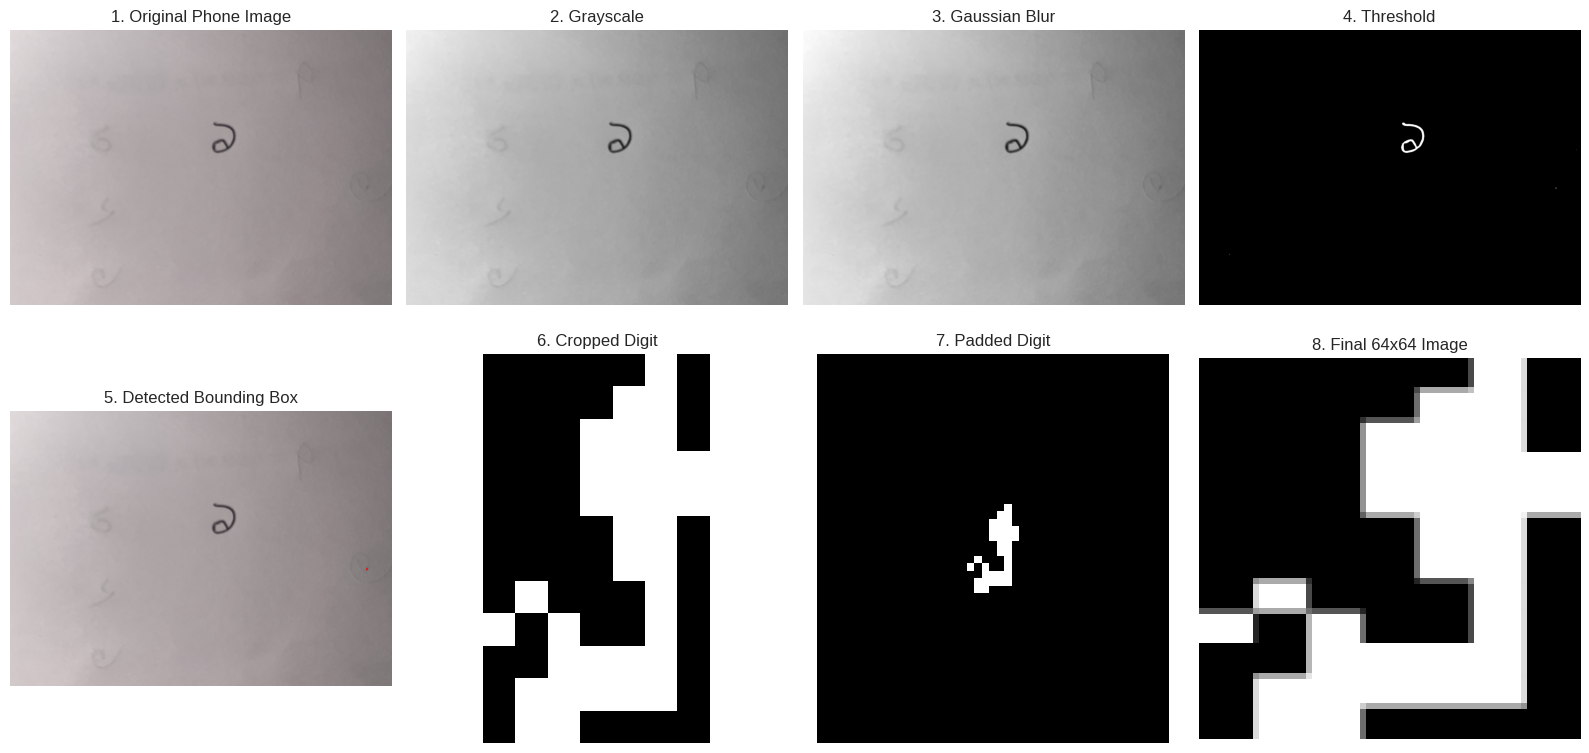

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


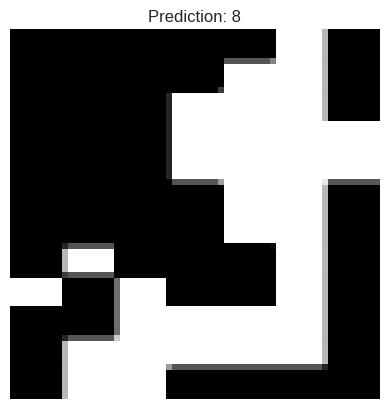

In [68]:
transfer_model.load_state_dict(torch.load('/kaggle/working/bangla_digit_sample/best_resnet50.pth',map_location = device))
pred_the_image(img_path = '/kaggle/input/datasets/tinonturjamajumder/an-image-of-a-bangla-digit/IMG_2782.jpg',
              model = transfer_model,
              device = device)

In [69]:
test_three_dataset = Path('/kaggle/working/bangla_digit_sample/data/test/3')
three_test = []
for files in test_three_dataset.iterdir():
    three_test.append(files)
len(three_test)

20

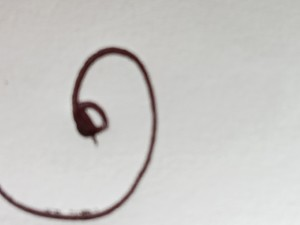

In [70]:
Image.open(three_test[0])